Цель эксперимента: Провести первичный разведочный анализ данных (EDA) синтетического датасета BNPL, выявить дисбаланс классов, изучить распределение признаков и найти потенциальные поведенческие инсайты для поиска фрода.
Какие данные используются: Исходный сэмпл транзакционных и демографических данных клиентов (cleaned_bnpl_data.csv).
Какие основные выводы: Обнаружен сильный дисбаланс классов (целевой признак Target имеет явное преобладание надежных клиентов). Визуализация показала явные различия в распределении кредитного рейтинга (Credit_Score) среди дефолтных и недефолтных пользователей, а также коммерчески значимые инсайты при анализе типов устройств (Device_Type) и типов интернет-соединений (Connection_Type), что подтверждает их важность для обучения моделей. Наличие выраженного миноритарного класса дефолтов полностью предопределяет выбор Recall (полноты) в качестве ключевой целевой метрики всего проекта.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/bnpl_dataset_v2.csv')


def map_target(status):
    if status == 'Paid On Time':
        return 0
    return 1

df['Target'] = df['Repayment_Status'].apply(map_target)

df_clean = df.drop(columns=['Transaction_ID', 'Repayment_Status'])

print("\nРаспределение классов (Target):")
print(df_clean['Target'].value_counts(normalize=True))

df_clean.to_csv('../data/cleaned_bnpl_data.csv', index=False)


Распределение классов (Target):
Target
0    0.76798
1    0.23202
Name: proportion, dtype: float64


C:\Users\fedor\AppData\Local\Temp\ipykernel_25528\3509598824.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Target', data=df_clean, palette=['#4CAF50', '#F44336'])


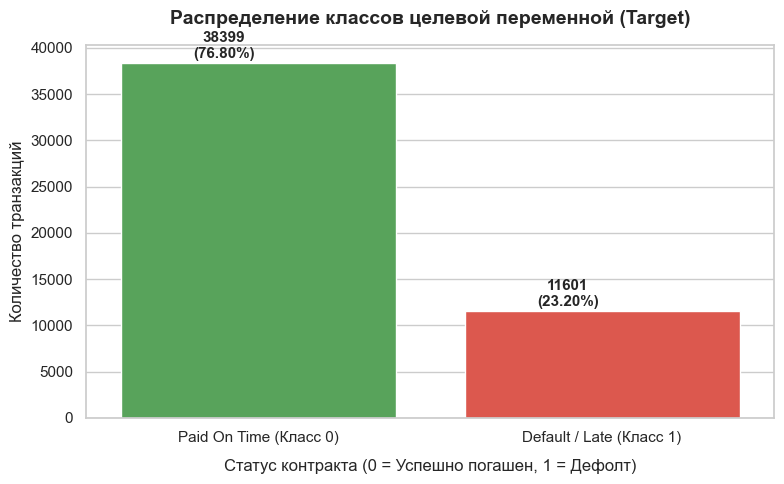

In [3]:

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

ax = sns.countplot(x='Target', data=df_clean, palette=['#4CAF50', '#F44336'])

plt.title('Распределение классов целевой переменной (Target)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Статус контракта (0 = Успешно погашен, 1 = Дефолт)', fontsize=12, labelpad=10)
plt.ylabel('Количество транзакций', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Paid On Time (Класс 0)', 'Default / Late (Класс 1)'])

total = len(df_clean)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    x_coord = p.get_x() + p.get_width() / 2 - 0.1
    y_coord = p.get_height() + 500
    ax.annotate(f'{int(p.get_height())}\n({percentage})', (x_coord, y_coord), fontsize=11, fontweight='bold', ha='center')

plt.tight_layout()
plt.show()

Пропущенные значения в колонках:
Customer_Age             0
Gender                   0
Annual_Income            0
Credit_Score             0
Purchase_Category        0
BNPL_Provider            0
Purchase_Amount          0
Device_Type              0
Connection_Type          0
Checkout_Time_Seconds    0
Browser                  0
Target                   0
dtype: int64
------------------------------


,Customer_Age,Annual_Income,Credit_Score,Purchase_Amount,Checkout_Time_Seconds,Target
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,40.979240,69980.860200,573.569300,563.221980,92.103000,0.232020
std,13.528733,28923.444012,158.853766,706.078491,50.762158,0.422126
min,18.000000,20000.000000,300.000000,20.000000,5.000000,0.000000
25%,29.000000,44915.500000,435.000000,124.000000,48.000000,0.000000
50%,41.000000,70071.500000,572.000000,229.000000,92.000000,0.000000
75%,53.000000,95262.250000,711.000000,785.000000,136.000000,0.000000
max,64.000000,119998.000000,849.000000,2999.000000,179.000000,1.000000


C:\Users\fedor\AppData\Local\Temp\ipykernel_25528\2758580278.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y='Credit_Score', data=df_clean, palette='Set2')


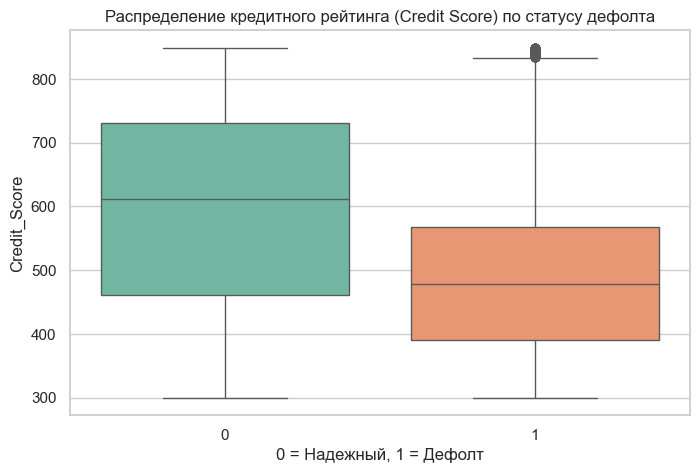

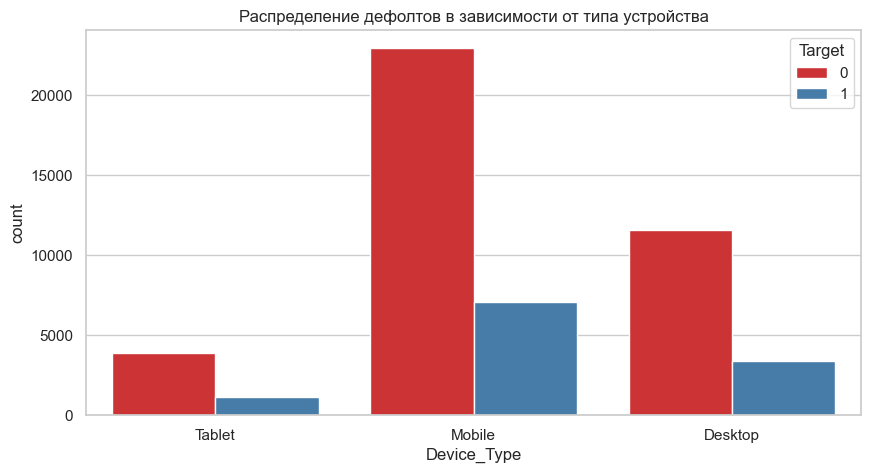

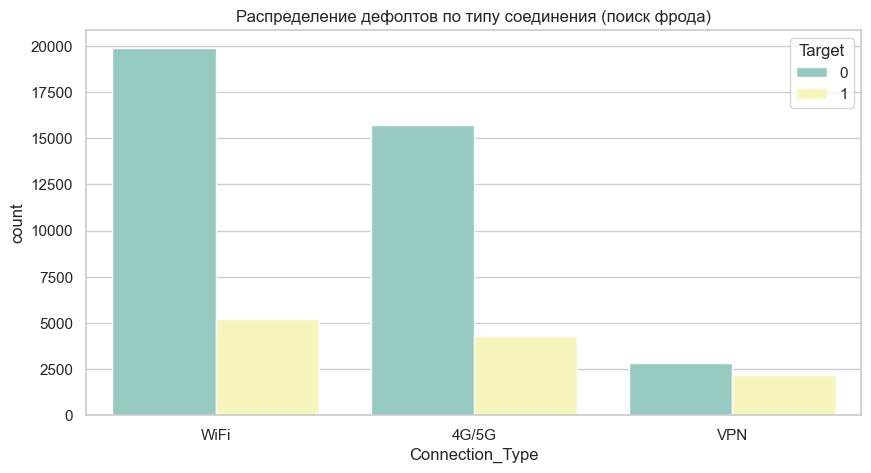

In [4]:

print("Пропущенные значения в колонках:")
print(df_clean.isnull().sum())
print("-" * 30)

display(df_clean.describe())

plt.figure(figsize=(8, 5))
sns.boxplot(x='Target', y='Credit_Score', data=df_clean, palette='Set2')
plt.title('Распределение кредитного рейтинга (Credit Score) по статусу дефолта')
plt.xlabel('0 = Надежный, 1 = Дефолт')
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(x='Device_Type', hue='Target', data=df_clean, palette='Set1')
plt.title('Распределение дефолтов в зависимости от типа устройства')
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(x='Connection_Type', hue='Target', data=df_clean, palette='Set3')
plt.title('Распределение дефолтов по типу соединения (поиск фрода)')
plt.show()